# Cell 1 - Title (Markdown)

# TORUS-2.0 — Remote Diagnostic Ultrasound Platform
### Tele-Operated Robotic Ultrasound System
## 05 — Train Follow-Up Prediction Model

**Objective:** Load the modeling dataset built in 04_build_modeling_dataset.ipynb, preprocess features, train a classifier to predict whether a patient exam requires follow-up, and evaluate model performance.

In [74]:
pip install scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [75]:
#Cell 2 - Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import joblib
import os

In [76]:
#Cell 3 - Load the modeling dataset

import pandas as pd

df = pd.read_csv("data/processed/modeling_dataset.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (800, 11)
   exam_id  patient_id  age sex risk_category device_id  exam_type  \
0        1          78   80   F        medium   DEV-003  obstetric   
1        2          62   65   F           low   DEV-001  obstetric   
2        3         132   18   F           low   DEV-004  obstetric   
3        4          89   51   M        medium   DEV-002   vascular   
4        5         237   25   M           low   DEV-003  abdominal   

  exam_timestamp  image_quality_score outcome_label  target  
0     2025-07-04                 0.88        normal       0  
1     2025-02-08                 0.98  inconclusive       0  
2     2025-08-11                 0.85  inconclusive       0  
3     2025-07-03                 0.65        normal       0  
4     2026-05-10                 0.55        normal       0  


In [77]:
#Cell 4 - Basic checks

print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['target'].value_counts(normalize=True))

exam_id                  int64
patient_id               int64
age                      int64
sex                     object
risk_category           object
device_id               object
exam_type               object
exam_timestamp          object
image_quality_score    float64
outcome_label           object
target                   int64
dtype: object

Missing values:
 exam_id                0
patient_id             0
age                    0
sex                    0
risk_category          0
device_id              0
exam_type              0
exam_timestamp         0
image_quality_score    0
outcome_label          0
target                 0
dtype: int64

Target distribution:
 target
0    0.7525
1    0.2475
Name: proportion, dtype: float64


In [78]:
#Cell 5 - Define features and target

feature_cols = [
    "age",
    "sex",
    "risk_category",
    "device_id",
    "exam_type",
    "image_quality_score",
]

target_col = "target"

X = df[feature_cols]
y = df[target_col]

categorical_cols = ["sex", "risk_category", "device_id", "exam_type"]
numeric_cols = ["age", "image_quality_score"]

In [79]:
#Cell 6 - Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (640, 6)
Test shape: (160, 6)


In [80]:
#Cell 7 - Build preprocessing + model pipelines

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="passthrough"
)

log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        class_weight="balanced"
    ))
])

In [81]:
#Cell 8 — Train Logistic Regression baseline

log_reg_pipeline.fit(X_train, y_train)

y_pred_lr = log_reg_pipeline.predict(X_test)
y_proba_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Logistic Regression Results
Accuracy : 0.4875
Precision: 0.2375
Recall   : 0.475
F1 Score : 0.31666666666666665


In [82]:
#Cell 9 — Train Random Forest model

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest Results
Accuracy : 0.71875
Precision: 0.2727272727272727
Recall   : 0.075
F1 Score : 0.11764705882352941


In [83]:
#Cell 10 — Detailed classification reports

print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))

print("\nRandom Forest Report:\n")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.74      0.49      0.59       120
           1       0.24      0.47      0.32        40

    accuracy                           0.49       160
   macro avg       0.49      0.48      0.45       160
weighted avg       0.61      0.49      0.52       160


Random Forest Report:

              precision    recall  f1-score   support

           0       0.75      0.93      0.83       120
           1       0.27      0.07      0.12        40

    accuracy                           0.72       160
   macro avg       0.51      0.50      0.48       160
weighted avg       0.63      0.72      0.65       160



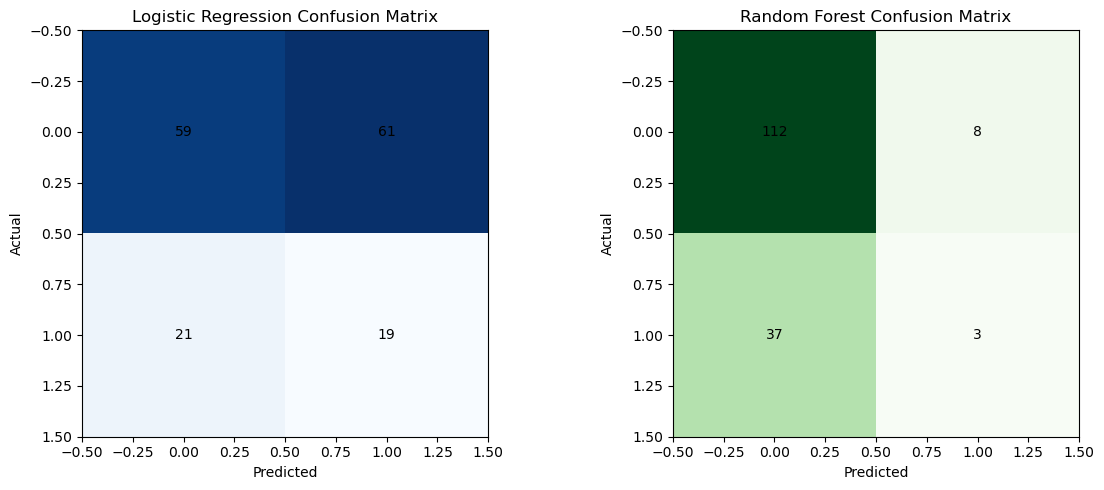

In [84]:
#Cell 11 — Confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
axes[0].imshow(cm_lr, cmap="Blues")
axes[0].set_title("Logistic Regression Confusion Matrix")
for (i, j), val in np.ndenumerate(cm_lr):
    axes[0].text(j, i, val, ha="center", va="center")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_rf = confusion_matrix(y_test, y_pred_rf)
axes[1].imshow(cm_rf, cmap="Greens")
axes[1].set_title("Random Forest Confusion Matrix")
for (i, j), val in np.ndenumerate(cm_rf):
    axes[1].text(j, i, val, ha="center", va="center")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

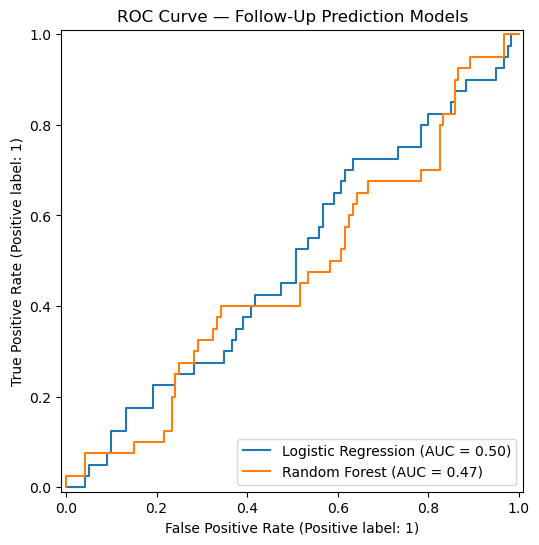

In [85]:
#Cell 12 — ROC curve comparison

fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="Random Forest", ax=ax)

ax.set_title("ROC Curve — Follow-Up Prediction Models")
plt.show()

In [86]:
#Cell 13 — Feature importance (Random Forest)

ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = list(cat_feature_names) + numeric_cols

importances = rf_pipeline.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
14,image_quality_score,0.312847
13,age,0.288422
9,exam_type_abdominal,0.037447
5,device_id_DEV-001,0.034901
3,risk_category_low,0.032984
6,device_id_DEV-002,0.032414
8,device_id_DEV-004,0.031831
7,device_id_DEV-003,0.031367
4,risk_category_medium,0.030353
12,exam_type_vascular,0.029683


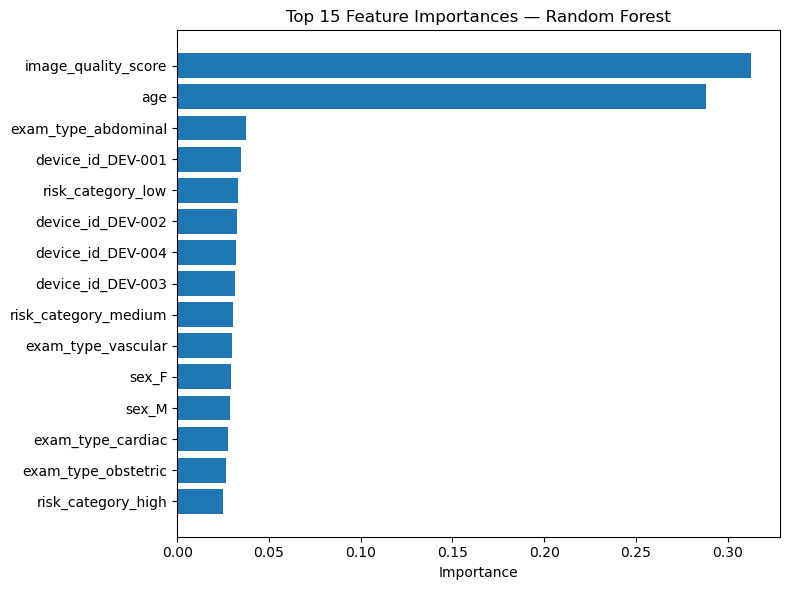

In [87]:
#Cell 14 — Plot feature importances


plt.figure(figsize=(8, 6))
top_features = importance_df.head(15)
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [88]:
#Cell 15 — Select best model and save


best_model = rf_pipeline if f1_score(y_test, y_pred_rf) >= f1_score(y_test, y_pred_lr) else log_reg_pipeline
best_model_name = "random_forest" if best_model is rf_pipeline else "logistic_regression"

print(f"Best model selected: {best_model_name}")

os.makedirs("models", exist_ok=True)
model_path = f"models/followup_prediction_{best_model_name}.pkl"

joblib.dump(best_model, model_path)
print(f"Model saved to {model_path}")

Best model selected: logistic_regression
Model saved to models/followup_prediction_logistic_regression.pkl


In [73]:
#Cell 16 — Save evaluation metrics summary


results = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "accuracy": [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    "precision": [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    "recall": [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    "f1_score": [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
})

os.makedirs("data/processed", exist_ok=True)
results.to_csv("data/processed/model_evaluation_results.csv", index=False)

results

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.48750,0.237500,0.475,0.316667
1,Random Forest,0.71875,0.272727,0.075,0.117647


In [89]:
import pandas, numpy, sqlalchemy, sklearn, matplotlib
print("pandas==" + pandas.__version__)
print("numpy==" + numpy.__version__)
print("SQLAlchemy==" + sqlalchemy.__version__)
print("scikit-learn==" + sklearn.__version__)
print("matplotlib==" + matplotlib.__version__)

pandas==2.2.3
numpy==2.1.3
SQLAlchemy==2.0.39
scikit-learn==1.7.2
matplotlib==3.10.0


In [90]:
import psycopg2, joblib
print("psycopg2-binary==" + psycopg2.__version__)
print("joblib==" + joblib.__version__)

psycopg2-binary==2.9.12 (dt dec pq3 ext lo64)
joblib==1.4.2


In [94]:
!pip install fastapi uvicorn

  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)

   ---------------- ----------------------- 2/5 [uvicorn]
   ---------------- ----------------------- 2/5 [uvicorn]
   ---------------- ----------------------- 2/5 [uvicorn]
   ---------------- ----------------------- 2/5 [uvicorn]
   ------------------------ --------------- 3/5 [starlette]
   ------------------------ --------------- 3/5 [starlette]
   ------------------------ --------------- 3/5 [starlette]
   -------------------------------- ------- 4/5 [fastapi]
   -------------------------------- ------- 4/5 [fastapi]
   -------------------------------- ------- 4/5 [fastapi]
   -------------------------------- ------- 4/5 [fastapi]
   ---------------------------------------- 5/5 [fastapi]



In [95]:
import fastapi, uvicorn
print("fastapi==" + fastapi.__version__)
print("uvicorn==" + uvicorn.__version__)

fastapi==0.139.2
uvicorn==0.51.0
